# Pipeline de Segmentação Semântica com U-Net ResNet18

Este notebook apresenta o fluxo completo da pipeline de segmentação semântica, estruturado em duas etapas principais:
1. **Parte 0 — Teste Unitário Sintético**: Geração e validação rápida em um dataset sintético de elipses.
2. **Parte 1 — Dados Reais (DSB2018 / )**: Carregamento, fusão de máscaras de núcleos e avaliação em imagens reais de microscopia.

> **Estrutura de Código**: As funções auxiliares, arquitetura do modelo, data loaders, treino e métricas estão modularizadas no arquivo  para manter o notebook limpo e focado no fluxo de execução.


In [34]:
# 1. Configuração do Ambiente e Inicialização do Dispositivo
import torch
import numpy as np
from utils import (
    get_device,
    UNetResNet,
    gerar_dataset_elipses,
    carregar_dataset_real,
    split_dataset,
    train_model,
    evaluate_model,
    plot_dataset_samples,
    plot_predictions
)

device = get_device()
print(f"Dispositivo selecionado para execução: {device}")


Dispositivo selecionado para execução: mps


In [35]:
# 2. Inicialização da Arquitetura do Modelo U-Net com Backbone ResNet18
model_test = UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True).to(device)

# Teste de Sanidade do Formato de Saída (Batch dummy de tamanho 2x3x128x128)
dummy_in = torch.randn(2, 3, 128, 128, device=device)
dummy_out = model_test(dummy_in)
print(f"Arquitetura carregada. Dimensão do tensor de saída: {tuple(dummy_out.shape)}")


Arquitetura carregada. Dimensão do tensor de saída: (2, 1, 128, 128)


## Parte 0 — Teste Unitário com Dataset Sintético
Nesta etapa, geramos 100 imagens sintéticas contendo elipses sobrepostas e dividimos os dados em **Treino (70%)**, **Validação (15%)** e **Teste (15%)**.


In [36]:
# 3. Geração do Dataset Sintético de Elipses e Divisão dos Dados (X_train, X_val, X_test)
images_synth, masks_synth = gerar_dataset_elipses(num_images=100, image_size=(128, 128), seed=42)

X_train_synth, y_train_synth, X_val_synth, y_val_synth, X_test_synth, y_test_synth = split_dataset(
    images_synth, masks_synth, train_ratio=0.70, val_ratio=0.15, seed=42
)

print(f"[Sintético] Conjunto de Treino:   X={X_train_synth.shape}, y={y_train_synth.shape}")
print(f"[Sintético] Conjunto de Validação: X={X_val_synth.shape}, y={y_val_synth.shape}")
print(f"[Sintético] Conjunto de Teste:     X={X_test_synth.shape}, y={y_test_synth.shape}")


[Sintético] Conjunto de Treino:   X=(70, 128, 128, 3), y=(70, 128, 128)
[Sintético] Conjunto de Validação: X=(15, 128, 128, 3), y=(15, 128, 128)
[Sintético] Conjunto de Teste:     X=(15, 128, 128, 3), y=(15, 128, 128)


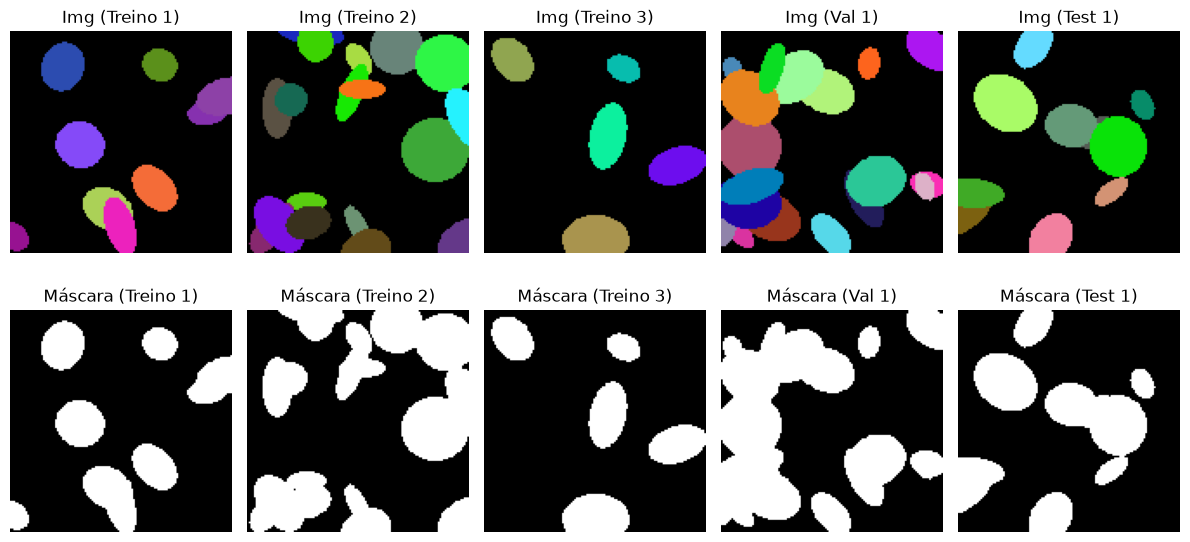

In [37]:
# 4. Visualização de Amostras do Dataset Sintético
plot_dataset_samples(X_train_synth, y_train_synth, X_val_synth, y_val_synth, X_test_synth, y_test_synth)


In [38]:
# 5. Treinamento da U-Net no Dataset Sintético
model_synth = UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
print("=== Treinamento no Dataset Sintético ===")
train_model(
    model=model_synth,
    X_train=X_train_synth,
    y_train=y_train_synth,
    X_val=X_val_synth,
    y_val=y_val_synth,
    device=device,
    num_epochs=10,
    batch_size=8,
    learning_rate=0.001
)


=== Treinamento no Dataset Sintético ===
Epoch [ 1/10] | Train Loss: 0.3467 | Val Loss: 0.5617
Epoch [ 2/10] | Train Loss: 0.2138 | Val Loss: 0.3579
Epoch [ 3/10] | Train Loss: 0.1745 | Val Loss: 0.2361
Epoch [ 4/10] | Train Loss: 0.1462 | Val Loss: 0.1602
Epoch [ 5/10] | Train Loss: 0.1244 | Val Loss: 0.1343
Epoch [ 6/10] | Train Loss: 0.1069 | Val Loss: 0.1132
Epoch [ 7/10] | Train Loss: 0.0929 | Val Loss: 0.0942
Epoch [ 8/10] | Train Loss: 0.0818 | Val Loss: 0.0803
Epoch [ 9/10] | Train Loss: 0.0731 | Val Loss: 0.0709
Epoch [10/10] | Train Loss: 0.0660 | Val Loss: 0.0634


In [39]:
# 6. Avaliação Quantitativa no Teste Sintético (Dice & IoU)
test_dice_synth, test_iou_synth = evaluate_model(model_synth, X_test_synth, y_test_synth, device=device)
print(f"--- Avaliação no Teste Sintético (X_test_synth) ---")
print(f"Mean Dice Coefficient: {test_dice_synth:.4f}")
print(f"Mean IoU (Jaccard Index): {test_iou_synth:.4f}")


--- Avaliação no Teste Sintético (X_test_synth) ---
Mean Dice Coefficient: 0.9829
Mean IoU (Jaccard Index): 0.9665


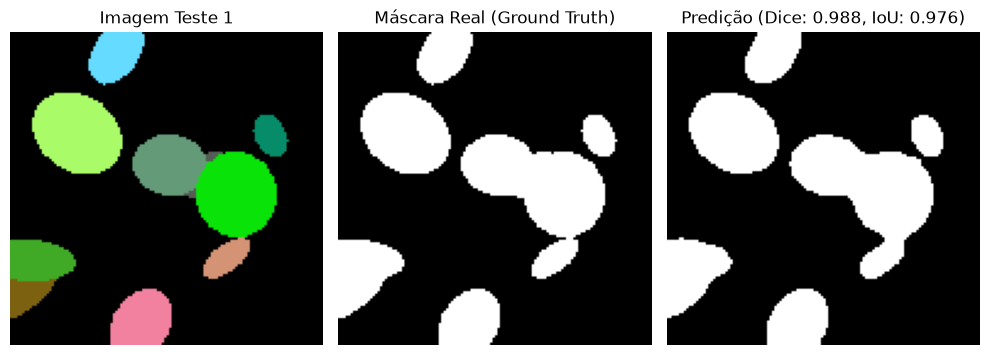

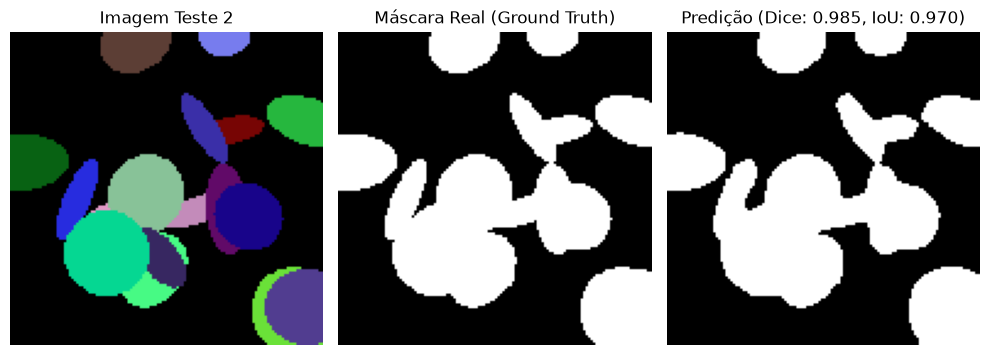

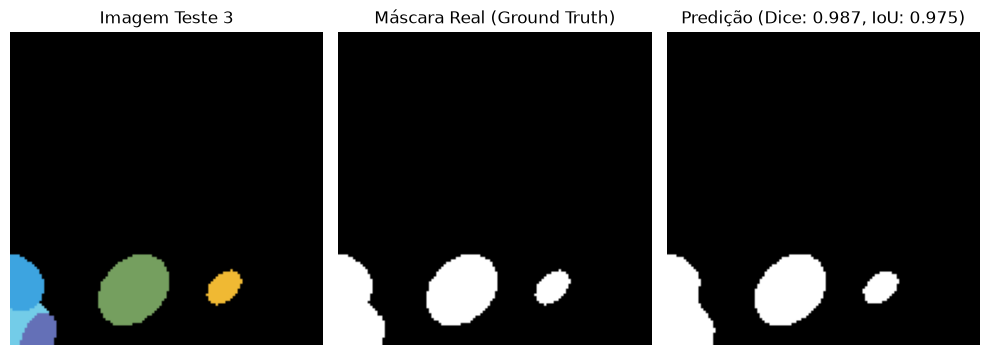

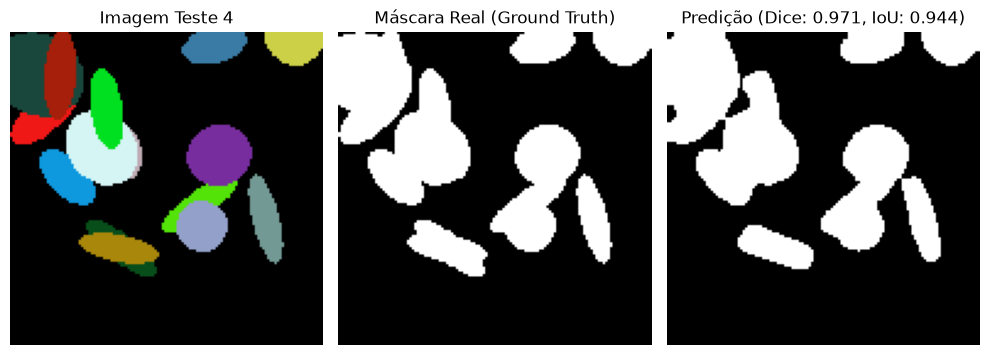

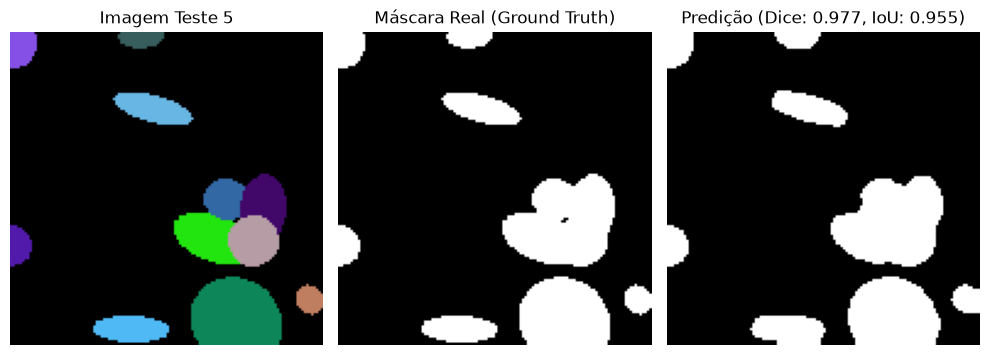

In [40]:
# 7. Visualização das Predições no Teste Sintético
plot_predictions(model_synth, X_test_synth, y_test_synth, device=device, num_samples=5)


## Parte 1 — Segmentação Semântica nos Dados Reais
Carregamento das 670 amostras de microscopia do Data Science Bowl 2018. Múltiplas máscaras individuais de núcleos por imagem são combinadas em uma única máscara de segmentação binária.


In [41]:
# 8. Carregamento e Pré-processamento dos Dados Reais (DSB2018)
stage1_path = "stage1_train"
images_real, masks_real = carregar_dataset_real(stage1_path, target_size=(128, 128))

# Divisão em Treino (70%), Validação (15%) e Teste (15%)
X_train_real, y_train_real, X_val_real, y_val_real, X_test_real, y_test_real = split_dataset(
    images_real, masks_real, train_ratio=0.70, val_ratio=0.15, seed=42
)

print(f"[Dados Reais] Conjunto de Treino:   X={X_train_real.shape}, y={y_train_real.shape}")
print(f"[Dados Reais] Conjunto de Validação: X={X_val_real.shape}, y={y_val_real.shape}")
print(f"[Dados Reais] Conjunto de Teste:     X={X_test_real.shape}, y={y_test_real.shape}")


Carregando 670 amostras de 'stage1_train'...
Dataset real carregado em 9.67 segundos!
[Dados Reais] Conjunto de Treino:   X=(468, 128, 128, 3), y=(468, 128, 128)
[Dados Reais] Conjunto de Validação: X=(101, 128, 128, 3), y=(101, 128, 128)
[Dados Reais] Conjunto de Teste:     X=(101, 128, 128, 3), y=(101, 128, 128)


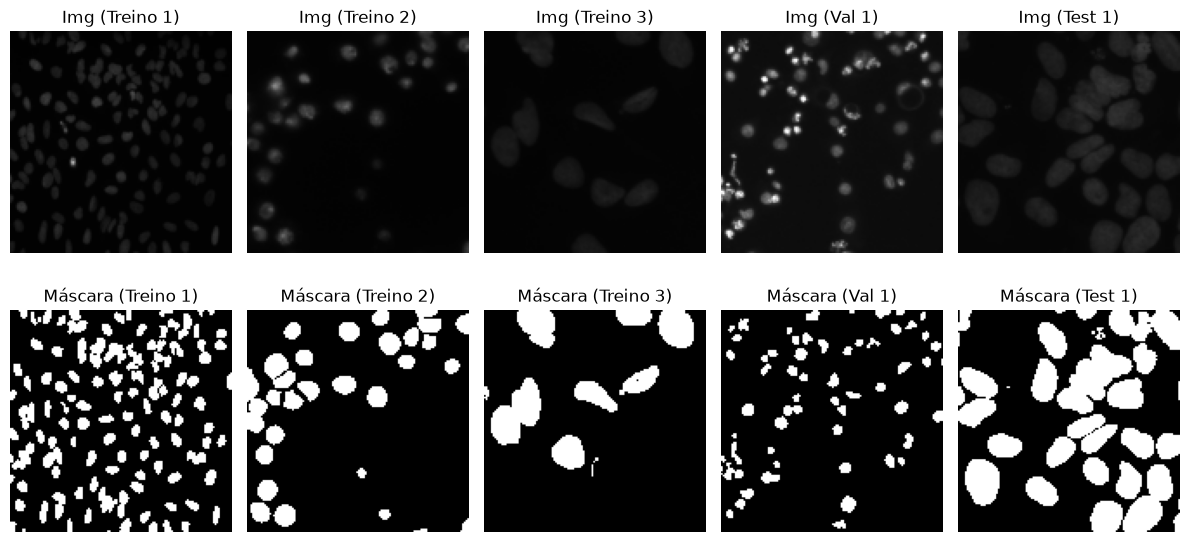

In [42]:
# 9. Visualização de Amostras do Dataset Real de Microscopia
plot_dataset_samples(X_train_real, y_train_real, X_val_real, y_val_real, X_test_real, y_test_real)


In [ ]:
# 10. Treinamento da U-Net nos Dados Reais
model_real = UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
print("=== Treinamento no Dataset Real (stage1_train) ===")
train_model(
    model=model_real,
    X_train=X_train_real,
    y_train=y_train_real,
    X_val=X_val_real,
    y_val=y_val_real,
    device=device,
    num_epochs=10,
    batch_size=16,
    learning_rate=0.001
)


=== Treinamento no Dataset Real (stage1_train) ===
Epoch [ 1/30] | Train Loss: 0.4750 | Val Loss: 0.4643
Epoch [ 2/30] | Train Loss: 0.2742 | Val Loss: 0.2487
Epoch [ 3/30] | Train Loss: 0.1988 | Val Loss: 0.1828
Epoch [ 4/30] | Train Loss: 0.1580 | Val Loss: 0.1473
Epoch [ 5/30] | Train Loss: 0.1345 | Val Loss: 0.1319
Epoch [ 6/30] | Train Loss: 0.1226 | Val Loss: 0.1216
Epoch [ 7/30] | Train Loss: 0.1100 | Val Loss: 0.1147
Epoch [ 8/30] | Train Loss: 0.1019 | Val Loss: 0.1094
Epoch [ 9/30] | Train Loss: 0.0958 | Val Loss: 0.1094
Epoch [10/30] | Train Loss: 0.0917 | Val Loss: 0.1070
Epoch [11/30] | Train Loss: 0.0903 | Val Loss: 0.1109
Epoch [12/30] | Train Loss: 0.0866 | Val Loss: 0.1065
Epoch [13/30] | Train Loss: 0.0804 | Val Loss: 0.1035
Epoch [14/30] | Train Loss: 0.0770 | Val Loss: 0.1039
Epoch [15/30] | Train Loss: 0.0750 | Val Loss: 0.1283
Epoch [16/30] | Train Loss: 0.0738 | Val Loss: 0.1278
Epoch [17/30] | Train Loss: 0.0747 | Val Loss: 0.1155
Epoch [18/30] | Train Loss: 0.0

In [49]:
# 11. Avaliação Quantitativa no Teste Real (Dice & IoU)
test_dice_real, test_iou_real = evaluate_model(model_real, X_test_real, y_test_real, device=device, batch_size=16)
print(f"--- Avaliação no Teste Real (X_test_real) ---")
print(f"Mean Dice Coefficient: {test_dice_real:.4f}")
print(f"Mean IoU (Jaccard Index): {test_iou_real:.4f}")


--- Avaliação no Teste Real (X_test_real) ---
Mean Dice Coefficient: 0.8538
Mean IoU (Jaccard Index): 0.7574


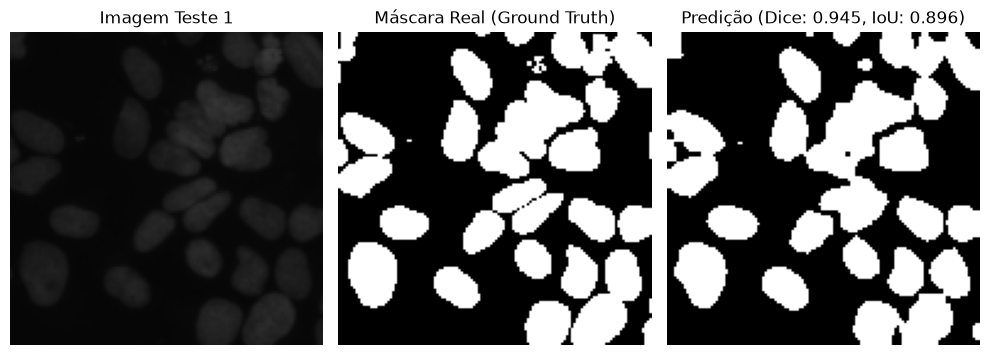

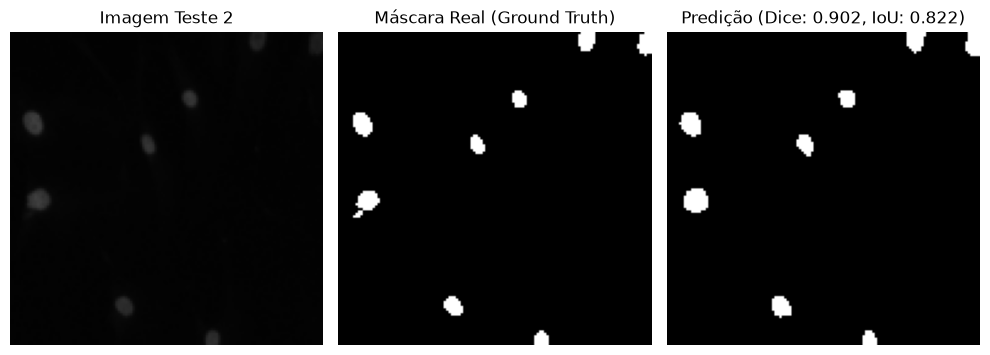

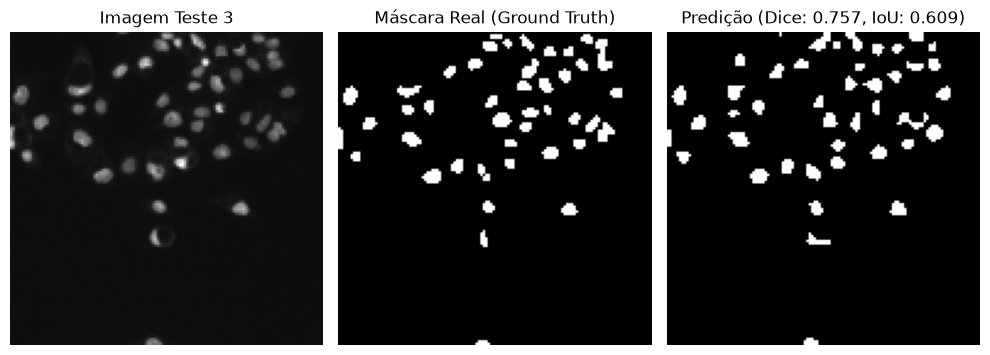

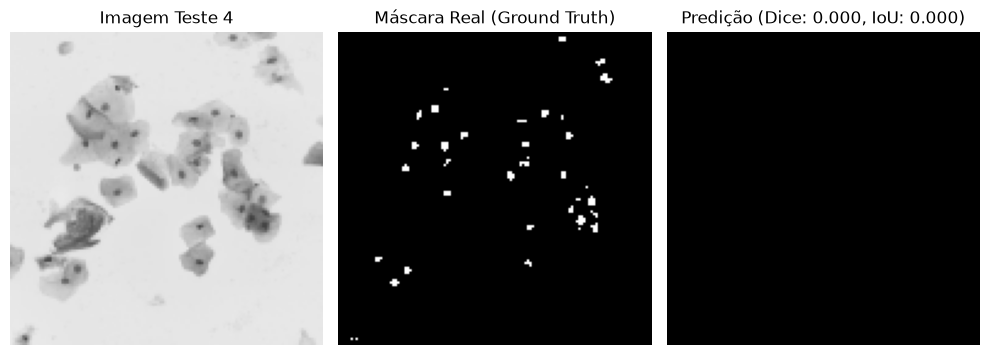

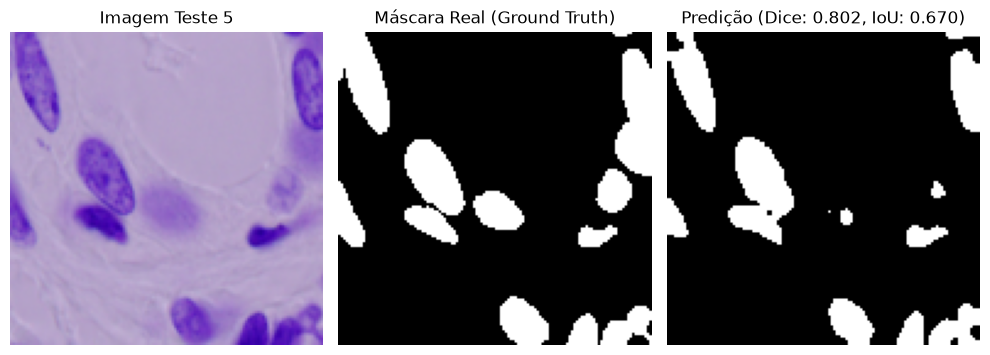

In [50]:
# 12. Visualização das Predições nas Imagens Reais de Teste
plot_predictions(model_real, X_test_real, y_test_real, device=device, num_samples=5)
